# VoxIntel — 05 Debugging: Fine-tune Wav2Vec2 on SLURP (Fixed Run)

## Why the previous `05_finetune_wav2vec2.ipynb` run failed

The previous run had `SMOKE_TEST = False` and `NUM_EPOCHS = 15` correctly
set, so on paper it should have been a full training run. But looking at
the actual training log, it stopped after **2,000 / 94,920 steps — about
0.32 epochs** — and the final validation WER (0.967) barely differs from
notebook 04's *pretrained, non-fine-tuned* baseline (0.984 corpus WER).

The root cause is visible directly in the logged eval metrics:

| Step | Training Loss | Eval WER | Eval CER |
|-----:|---------------:|---------:|---------:|
| 500  | 3.138           | 0.956482 | 0.966406 |
| 1000 | 1.802           | 0.956482 | 0.966406 |
| 1500 | 1.667           | 0.956482 | 0.966406 |
| 2000 | 1.593           | 0.956482 | 0.966406 |

Training loss was falling steadily (3.14 → 1.59), which means the model
**was** learning. But `eval_wer` was *bit-for-bit identical* across all
four eval checkpoints. That is not a coincidence — it is the classic CTC
**blank-collapse** phase: early in CTC training, the model routes almost
all probability mass to the blank token and predicts an empty (or
near-empty) transcript for everything, which produces a constant,
maximal WER regardless of small improvements in the underlying logits.
The model needs enough gradient steps to escape this regime before WER
starts moving at all.

`EarlyStoppingCallback(patience=3)` was watching `eval_wer`, saw the
*exact same* "best" value four times in a row, concluded there was no
further improvement possible, and killed training — right in the middle
of the collapse phase, before the model had any chance to escape it.
Two compounding factors made the collapse phase last longer than it
needed to:

- **`LR = 1e-4`** is aggressive for Wav2Vec2 CTC fine-tuning (commonly
  1e-5–5e-5 range), which can make early optimization less stable and
  slower to leave the blank-collapse basin.
- **`WARMUP_STEPS = 500`** is a fixed step count that, relative to a
  94,920-step schedule, is a very short (~0.5%) ramp — the learning rate
  reached full value almost immediately, rather than easing the model
  through the unstable early phase.

So: **the pipeline itself (data loading, collator, label alignment, CTC
validity filtering) is correct** — training loss decreasing proves that.
The failure was a *training-dynamics* bug: early stopping fired on a
metric that hadn't started moving yet, for a completely explainable
reason, and the aggressive LR/warmup combination made that window wider
than it needed to be.

## What's new in this notebook

Based on that diagnosis, plus the tuning pass previously done on this
notebook, this version changes:

| Change | Why |
|---|---|
| `LR: 1e-4 → 3e-5` | Standard Wav2Vec2 CTC fine-tuning range; less likely to destabilize early training |
| `warmup_ratio = 0.1` (was fixed `warmup_steps=500`) | Scales the ramp to the *actual* full-dataset schedule instead of a fixed, now-tiny fraction of it |
| **Delayed early stopping** (new custom callback) | Ignores `eval_wer` entirely for the first `MIN_STEPS_BEFORE_EARLY_STOPPING` steps, so blank-collapse can't be mistaken for convergence |
| `EARLY_STOPPING_PATIENCE: 3 → 10` | Extra margin per your choice, on top of the delay guard above |
| `lr_scheduler_type = "cosine"` | Smoother decay than the default linear schedule |
| `weight_decay = 0.01` | Was missing; standard regularization for this setup |
| `group_by_length = True` | Batches similarly-sized audio together — less wasted padding, more stable batch statistics |
| `gradient_checkpointing = True` | Trades compute for VRAM — needed headroom for the 6–8GB GPU this notebook is configured for |
| `fp16 = True` | Mixed precision — roughly halves activation memory, important at 6–8GB VRAM |
| `GRADIENT_ACCUMULATION_STEPS: 2 → 4` (effective batch 4×4=16, same per-step batch of 4) | Smoother gradients without raising per-step VRAM use |
| `EVAL_SUBSET_SIZE_DURING_TRAINING: 500 → 1000` | You said time isn't a constraint — a larger training-time eval subset gives a less noisy WER signal for checkpoint selection |
| `SMOKE_TEST = False`, full `train` split, full `NUM_EPOCHS = 15` | Per your instruction — this run trains on the complete dataset, no shrinking |

**`FREEZE_FEATURE_ENCODER` stays `True` for this run.** Unfreezing the
CNN feature encoder is a real lever (Strategy 2 in the earlier tuning
notes) but it's deliberately *not* mixed in here: this notebook changes
the training-dynamics bug and applies safe, standard hyperparameters in
one pass. Unfreezing is a separate, independent experiment — bundling it
in here would make it impossible to tell whether an improvement came
from fixing the bug or from unfreezing. Treat that as `05b` if you want
to run it next, after this run establishes a real fine-tuned baseline.

## A note on "perfect scores"

Genuinely perfect (0% WER) transcription isn't a realistic target for
any ASR system, including commercial ones — SLURP has noisy, accented,
naturalistic home-assistant audio, and some residual error rate is
expected even from strong models. What this notebook is built to do is
**get the model out of the blank-collapse trap and into a real training
regime**, so the WER you see actually reflects the model's fine-tuned
performance instead of an early-stopping artifact. Realistically, a
successful run here should land somewhere in the 15–35% WER range
depending on how far training gets — a large, real improvement over the
96.7%/58.4% baseline numbers, not a literal zero.


## Changelog vs the previous version (memory-pipeline fix)

A code review of this notebook flagged that the data pipeline was still
routing everything through `Dataset.from_list()` + `.map()` on top of an
already-existing custom `SLURPDataset`, which is what was causing the
`ArrowMemoryError`s and the double-decoding of every audio file. This
version replaces that pipeline while leaving the training-dynamics fix
(delayed early stopping, LR/warmup/scheduler) from the previous version
untouched:

- **Lazy preprocessing**: `Dataset.from_list()` + `.map()` is gone. A
  plain `torch.utils.data.Dataset` (`SLURPLazyDataset`) now decodes and
  processes exactly one example at a time, inside `__getitem__`, handed
  straight to the `DataLoader`/`Trainer`.
- **No more double-decoding**: `to_rows()` used to call `load_audio()`
  (a full decode) just to measure duration for filtering, and then
  decoded the same file again during preprocessing. It now reads
  duration from file metadata (`soundfile.info`) instead, so every file
  is decoded exactly once, lazily, during training.
- **CTC-validity filtering without decoding audio**: frame counts are
  now estimated from the cached duration (`duration * 16_000`) instead
  of requiring a full decode up front; label lengths still come from
  the (cheap, text-only) tokenizer call.
- **`group_by_length` still works**: since there's no more Arrow column
  to read lengths from, a small `LengthGroupedTrainer` subclass builds
  the length-grouped sampler from the same cached-duration lengths.
- **Dataset returns tensors, collator only pads**: `input_values` comes
  back from `SLURPLazyDataset.__getitem__` as a `torch.FloatTensor`
  instead of a NumPy array, so preprocessing and padding responsibilities
  no longer overlap in the collator.
- **DataLoader performance flags**: `persistent_workers`, `pin_memory`,
  and `prefetch_factor` are added now that per-item loading happens in
  worker processes, plus `dataloader_num_workers` raised from 2 to 4.


Make `src` importable, same as notebooks 03/04.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Imports

In [2]:
import json
import random
import dataclasses
from typing import Any, Dict, List, Union

import numpy as np
import soundfile as sf
import torch
import pandas as pd
import matplotlib.pyplot as plt
import evaluate
from transformers import (
    AutoProcessor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from transformers.trainer_pt_utils import LengthGroupedSampler

from src.data import SLURPDataset
from src.utils.audio import load_audio
from src.utils.text import normalize_text


c:\Users\ACER\anaconda3\envs\torch26\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

Everything that controls this run lives here. Compared to the previous
notebook, the training-dynamics parameters (`LR`, `WARMUP_RATIO`,
`EARLY_STOPPING_PATIENCE`, `MIN_STEPS_BEFORE_EARLY_STOPPING`) are the
ones responsible for actually fixing the bug — the rest are efficiency
and stability additions layered on top.


In [3]:
MODEL_NAME = "facebook/wav2vec2-base-960h"
ROOT_DIR = "C:\\Users\\ACER\\OneDrive\\Desktop\\VoxIntel\\data\\raw\\slurp"
TRAIN_SPLIT = "train"
VAL_SPLIT = "validation"
OUTPUT_DIR = PROJECT_ROOT / "models" / "wav2vec2_slurp_debug"
SEED = 42

# Full dataset, full run. No shrinking.
SMOKE_TEST = False

LR = 3e-5                     # was 1e-4 -- standard Wav2Vec2 CTC fine-tuning range
WARMUP_RATIO = 0.1            # was fixed WARMUP_STEPS=500 (~0.5% of the real schedule)
LR_SCHEDULER_TYPE = "cosine"  # smoother decay than default linear

# Early stopping fix 
# The previous run's early stopping fired while eval_wer was frozen during
# CTC blank-collapse (see markdown above). Two independent guards now:
#   1) a hard "don't even look at eval_wer" window early in training, and
#   2) a larger patience on top of that, per your preference.
MIN_STEPS_BEFORE_EARLY_STOPPING = 3000
EARLY_STOPPING_PATIENCE = 10

BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4   # effective batch = 16
GRADIENT_CHECKPOINTING = True
FP16 = True
GROUP_BY_LENGTH = True
WEIGHT_DECAY = 0.01

NUM_EPOCHS = 15
EVAL_STEPS = 500
SAVE_STEPS = 500

MAX_AUDIO_DURATION_SEC = 15
EVAL_SUBSET_SIZE_DURING_TRAINING = 1000   # was 500 -- time isn't a constraint here
FREEZE_FEATURE_ENCODER = True             # unchanged deliberately -- see markdown above

## Seed and device

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print("WARNING: no CUDA device found. This config assumes a 6-8GB GPU; "
          "training on CPU will be extremely slow for the full dataset.")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Total VRAM (GB): 4.29


## Load train and validation splits

Real audio only for both splits, same as before. `train_synthetic` is
still left out — that stays a follow-up experiment, not something to mix
in while we're isolating the training-dynamics fix.


In [5]:
train_set = SLURPDataset(split=TRAIN_SPLIT, root_dir=ROOT_DIR)
val_set = SLURPDataset(split=VAL_SPLIT, root_dir=ROOT_DIR)

print(train_set.summary())
print(val_set.summary())

{'split': 'train', 'n_samples': 50628, 'n_unique_intents': 91, 'n_missing_audio': 0, 'n_missing_transcript': 0, 'n_missing_intent': 0}
{'split': 'validation', 'n_samples': 8690, 'n_unique_intents': 71, 'n_missing_audio': 0, 'n_missing_transcript': 0, 'n_missing_intent': 0}


## Convert to plain rows (metadata-only duration -- no full audio decode)

Previously this called `load_audio()` (a full waveform decode) on every
file just to compute `duration = len(waveform) / sr` for the
max-duration filter, and then decoded the same file again later in
`preprocess_function`. Every file was read twice.

`soundfile.info()` reads only the file header (frame count and sample
rate), not the audio samples, so duration can be computed here for free.
The actual waveform is now decoded exactly once, lazily, inside
`SLURPLazyDataset.__getitem__` during training/evaluation.


In [6]:
def to_rows(dataset, max_duration=MAX_AUDIO_DURATION_SEC):
    rows = []
    skipped = {"no_audio": 0, "no_transcript": 0, "too_long": 0, "unreadable": 0}

    for sample in dataset:
        if not sample["audio_path"]:
            skipped["no_audio"] += 1
            continue
        if not sample["transcript"] or not sample["transcript"].strip():
            skipped["no_transcript"] += 1
            continue

        try:
            info = sf.info(sample["audio_path"])
            duration = info.frames / info.samplerate
        except Exception:
            skipped["unreadable"] += 1
            continue

        if duration > max_duration:
            skipped["too_long"] += 1
            continue

        rows.append({
            "audio_path": str(sample["audio_path"]),
            "sentence": sample["transcript"],
            "intent": sample["intent"],
            "scenario": sample["scenario"],
            "duration": duration,
        })

    print(f"Kept {len(rows)} / {len(dataset)} samples. Skipped: {skipped}")
    return rows


train_rows = to_rows(train_set)
val_rows = to_rows(val_set)


Kept 50619 / 50628 samples. Skipped: {'no_audio': 0, 'no_transcript': 0, 'too_long': 9, 'unreadable': 0}
Kept 8690 / 8690 samples. Skipped: {'no_audio': 0, 'no_transcript': 0, 'too_long': 0, 'unreadable': 0}


## Lazy preprocessing dataset (fixes the ArrowMemoryError)

This replaces `Dataset.from_list()` + `.map()` entirely. Instead of
eagerly decoding and caching every waveform into an Arrow table up
front, `SLURPLazyDataset` decodes and processes exactly one example at
a time, inside `__getitem__`, on demand from the `DataLoader`. Memory
usage stops scaling with dataset size and starts scaling with batch
size instead.

`lengths` is computed once from the cached `duration` metadata (no
audio decode), and is what `group_by_length` uses later via
`LengthGroupedTrainer`.


In [7]:
class SLURPLazyDataset(torch.utils.data.Dataset):
    """On-the-fly preprocessing dataset for Wav2Vec2 CTC fine-tuning.

    Audio is decoded and run through the processor one example at a
    time, inside __getitem__, instead of being eagerly materialized
    into an Arrow table via Dataset.from_list() + .map(). This is what
    keeps memory usage flat regardless of dataset size.
    """

    def __init__(self, rows, processor, target_sr=16_000):
        self.rows = rows
        self.processor = processor
        self.target_sr = target_sr
        # Derived from duration metadata cached in to_rows() -- no decode.
        self.lengths = [int(r["duration"] * target_sr) for r in rows]

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        waveform, sr = load_audio(row["audio_path"], target_sr=self.target_sr)

        input_values = self.processor(
            waveform,
            sampling_rate=sr,
        ).input_values[0]

        labels = self.processor(
            text=normalize_text(row["sentence"]).upper(),
            return_attention_mask=False,
        ).input_ids

        return {
            "input_values": torch.as_tensor(input_values, dtype=torch.float32),
            "labels": labels,
        }


## Smoke-test subset (disabled)

`SMOKE_TEST = False` for this run -- the full train and validation
splits are used, no shrinking. Operates on the plain row lists now
rather than an HF `Dataset`, since there's no Arrow table anymore.


In [8]:
if SMOKE_TEST:
    train_rows = train_rows[: min(200, len(train_rows))]
    val_rows = val_rows[: min(50, len(val_rows))]

print(f"train_rows: {len(train_rows)}, val_rows: {len(val_rows)}")


train_rows: 50619, val_rows: 8690


## Load processor

In [10]:
processor = AutoProcessor.from_pretrained(MODEL_NAME)

## Drop CTC-invalid examples (metadata + tokenizer only, no audio decode)

Same CTC-validity rule as before (the conv feature extractor downsamples
audio by roughly 320x, so the resulting frame count must be at least as
long as the label sequence), but computed without decoding any audio:

- The post-conv-encoder frame count is estimated from the cached
  `duration` (`duration * 16_000 // 320`). Resampling preserves
  wall-clock duration, so this matches the true resampled frame count.
- The label length still comes from the tokenizer, which is cheap
  (text-only, no audio involved).


In [11]:
def is_ctc_valid(row, processor, target_sr=16_000, downsample_factor=320):
    approx_input_length = int(row["duration"] * target_sr)
    output_length = approx_input_length // downsample_factor

    label_ids = processor(
        text=normalize_text(row["sentence"]),
        return_attention_mask=False,
    ).input_ids
    return output_length >= len(label_ids)


def filter_rows(rows, processor):
    before = len(rows)
    kept = [r for r in rows if is_ctc_valid(r, processor)]
    print(f"kept {len(kept)} / {before}")
    return kept


train_rows = filter_rows(train_rows, processor)
val_rows = filter_rows(val_rows, processor)

kept 50619 / 50619
kept 8690 / 8690


## Two-tier validation set

`val_rows_train` is a 1,000-example subset used during training (a
larger, less noisy training-time eval signal). `val_rows` (all of
validation) is reserved for the one full pass at the end, directly
comparable to notebook 04's baseline.


In [12]:
eval_subset_size = min(EVAL_SUBSET_SIZE_DURING_TRAINING, len(val_rows))
val_rows_train = val_rows[:eval_subset_size]

print(f"val_rows_train (used during training): {len(val_rows_train)}")
print(f"val_rows (used for final evaluation): {len(val_rows)}")

val_rows_train (used during training): 1000
val_rows (used for final evaluation): 8690


## Wrap rows in the lazy dataset

In [13]:
train_proc = SLURPLazyDataset(train_rows, processor)
val_proc_train = SLURPLazyDataset(val_rows_train, processor)
val_proc_full = SLURPLazyDataset(val_rows, processor)

print(
    f"train_proc: {len(train_proc)} | "
    f"val_proc_train: {len(val_proc_train)} | "
    f"val_proc_full: {len(val_proc_full)}"
)


train_proc: 50619 | val_proc_train: 1000 | val_proc_full: 8690


## Data collator for CTC

Standard Wav2Vec2 CTC collator: pads `input_values` and `labels`
separately and replaces label padding with -100. `SLURPLazyDataset`
already returns `input_values` as a `torch.FloatTensor`, so
preprocessing and padding responsibilities no longer overlap here --
the collator's only job is padding.


In [14]:
@dataclasses.dataclass
class DataCollatorCTCWithPadding:
    processor: Any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]):

        input_features = [
            {"input_values": f["input_values"]}
            for f in features
        ]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        label_features = [
            {"input_ids": f["labels"]}
            for f in features
        ]

        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1),
            -100,
        )

        batch["labels"] = labels

        return batch


data_collator = DataCollatorCTCWithPadding(processor)

## Evaluation metric function

Unchanged: WER and CER computed on decoded predictions during training.
This is the metric that was frozen during blank-collapse in the previous
run — the fix here is in when/how it's allowed to trigger early stopping,
not in how it's computed.


In [15]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")


def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(label_ids, group_tokens=False)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer, "cer": cer}

## Load pretrained model

`FREEZE_FEATURE_ENCODER` stays on, same reasoning as before: the CNN
feature encoder was learned on 960 hours of clean audiobook audio, and
freezing it protects those low-level acoustic features while the rest
of the model adapts to SLURP.

New here: `model.gradient_checkpointing_enable()`, needed to keep memory
usage inside a 6-8GB budget with `fp16` training. `ctc_zero_infinity=True`
is unchanged — extra safety against any remaining frame-length-vs-label
mismatch.


In [16]:
model = Wav2Vec2ForCTC.from_pretrained(
    MODEL_NAME,
    ctc_loss_reduction="mean",
    ctc_zero_infinity=True,
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
)

if FREEZE_FEATURE_ENCODER:
    model.freeze_feature_encoder()

if GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    model.config.use_cache = False  # required whenever gradient checkpointing is on

model.to(DEVICE)

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 552.65it/s, Materializing param=wav2vec2.feature_projection.projection.weight]                         
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

## Delayed early stopping callback

This is the core fix for the bug diagnosed above. A plain
`EarlyStoppingCallback` starts counting non-improving evals from step 1
— which is exactly what killed the previous run during blank-collapse.
This subclass ignores evaluation results entirely until
`MIN_STEPS_BEFORE_EARLY_STOPPING` has passed, and only then hands control
to the normal `EarlyStoppingCallback` logic with `EARLY_STOPPING_PATIENCE`
patience.


In [17]:
class DelayedEarlyStoppingCallback(EarlyStoppingCallback):
    def __init__(self, min_steps_before_stopping, **kwargs):
        super().__init__(**kwargs)
        self.min_steps_before_stopping = min_steps_before_stopping

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if state.global_step < self.min_steps_before_stopping:
            print(
                f"[DelayedEarlyStopping] step {state.global_step} < "
                f"{self.min_steps_before_stopping}: eval_wer not yet considered "
                f"for early stopping (still inside the CTC warm-up window)."
            )
            return control
        return super().on_evaluate(args, state, control, metrics=metrics, **kwargs)


early_stopping_callback = DelayedEarlyStoppingCallback(
    min_steps_before_stopping=MIN_STEPS_BEFORE_EARLY_STOPPING,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)

## Training arguments

`THESE ARE CHANGED WILL UPDATE IT LATER`


In [19]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    gradient_checkpointing=GRADIENT_CHECKPOINTING,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    num_train_epochs=NUM_EPOCHS,
    fp16=FP16,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    logging_steps=100,
    report_to=[],
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    seed=SEED,
)

print(training_args)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=False,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=500,
eval_strategy=steps,
eval_use_gather_object=False,
fp16=True,
fp1

## Length-grouped trainer

Small `Trainer` subclass that restores `group_by_length` bucketing for a
plain `torch.utils.data.Dataset`. It builds the same
`LengthGroupedSampler` the built-in path would use, but sources lengths
from `train_dataset.lengths` (cached duration metadata, no decode)
instead of an Arrow column that no longer exists.


In [20]:
class LengthGroupedTrainer(Trainer):
    def _get_train_sampler(self, *args, **kwargs):
        dataset = args[0] if args else kwargs.get("train_dataset", self.train_dataset)

        if GROUP_BY_LENGTH and hasattr(dataset, "lengths"):
            return LengthGroupedSampler(
                self.args.train_batch_size * self.args.gradient_accumulation_steps,
                lengths=dataset.lengths,
            )

        return super()._get_train_sampler(*args, **kwargs)

## Trainer

In [21]:
trainer = LengthGroupedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_proc,
    eval_dataset=val_proc_train,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor,
    callbacks=[early_stopping_callback],
)

## Sanity check before committing to the full run

Before launching a multi-day training run, it's worth confirming the
model is not still in a degenerate state at initialization. This runs a
single evaluation pass on the small `val_proc_train` subset with the
*untrained* model, just to confirm the pipeline produces sane (if bad)
output before training starts. Expect a very high WER here — that's
normal and expected for an untrained/pretrained-only checkpoint.


In [22]:
sample = train_proc[0]

print(sample.keys())

for k, v in sample.items():
    if hasattr(v, "shape"):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v))

dict_keys(['input_values', 'labels'])
input_values torch.Size([12287]) torch.float32
labels <class 'list'>


In [23]:
import time

t0 = time.time()

for i in range(10):
    _ = train_proc[i]

print("10 samples:", time.time() - t0)

10 samples: 0.10076594352722168


In [24]:
sanity_metrics = trainer.evaluate(eval_dataset=val_proc_train)
print("Pre-training sanity check (expect a high WER — this is the untrained starting point):")
sanity_metrics

[DelayedEarlyStopping] step 0 < 3000: eval_wer not yet considered for early stopping (still inside the CTC warm-up window).
Pre-training sanity check (expect a high WER — this is the untrained starting point):


{'eval_loss': 2.1516826152801514,
 'eval_model_preparation_time': 0.0045,
 'eval_wer': 0.5876728449543983,
 'eval_cer': 0.3069064042252302,
 'eval_runtime': 20.088,
 'eval_samples_per_second': 49.781,
 'eval_steps_per_second': 12.445}

## Train

Full run: `SMOKE_TEST = False`, full `train` split, up to `NUM_EPOCHS`
epochs, with early stopping now correctly delayed past the expected
blank-collapse window. Given the "time isn't a constraint" preference,
this is left to run to completion or until early stopping genuinely
triggers after real convergence — watch that `eval_wer` actually starts
decreasing (not just staying flat) once you're past step
`MIN_STEPS_BEFORE_EARLY_STOPPING`.


In [25]:
trainer.train()

Step,Training Loss,Validation Loss,Model Preparation Time,Wer,Cer
500,6.833553,1.245563,0.004500,0.534422,0.273976
1000,5.910887,1.055142,0.004500,0.480141,0.242460
1500,5.056271,0.937264,0.004500,0.425272,0.215446
2000,5.095397,0.923254,0.004500,0.393498,0.201362
2500,4.744652,0.833823,0.004500,0.366137,0.187365
3000,4.388370,0.741116,0.004500,0.353045,0.179111
3500,4.185906,0.720173,0.004500,0.343189,0.172213
4000,3.876724,0.689597,0.004500,0.327891,0.164969
4500,4.061798,0.649045,0.004500,0.324654,0.163439
5000,3.808855,0.631424,0.004500,0.311562,0.158100


[DelayedEarlyStopping] step 500 < 3000: eval_wer not yet considered for early stopping (still inside the CTC warm-up window).


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.28it/s]


[DelayedEarlyStopping] step 1000 < 3000: eval_wer not yet considered for early stopping (still inside the CTC warm-up window).


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.38it/s]


...

[DelayedEarlyStopping] step 2000 < 3000: eval_wer not yet considered for early stopping (still inside the CTC warm-up window).


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]


[DelayedEarlyStopping] step 2500 < 3000: eval_wer not yet considered for early stopping (still inside the CTC warm-up window).


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.67it/s]


TrainOutput(global_step=46500, training_loss=2.5838895066784273, metrics={'train_runtime': 31307.6027, 'train_samples_per_second': 24.252, 'train_steps_per_second': 1.516, 'total_flos': 1.9418902143789085e+19, 'train_loss': 2.5838895066784273, 'epoch': 14.696641643619122})

## Training curves

Same three-panel plot as before: training loss, eval loss, eval WER.
The key thing to check this time: does `eval_wer` actually move (not a
flat line) once training passes `MIN_STEPS_BEFORE_EARLY_STOPPING`? If it's
still flat well past that point, that's a sign something else needs
attention (LR too low now, or a genuine data/label issue) rather than
early stopping being the culprit.


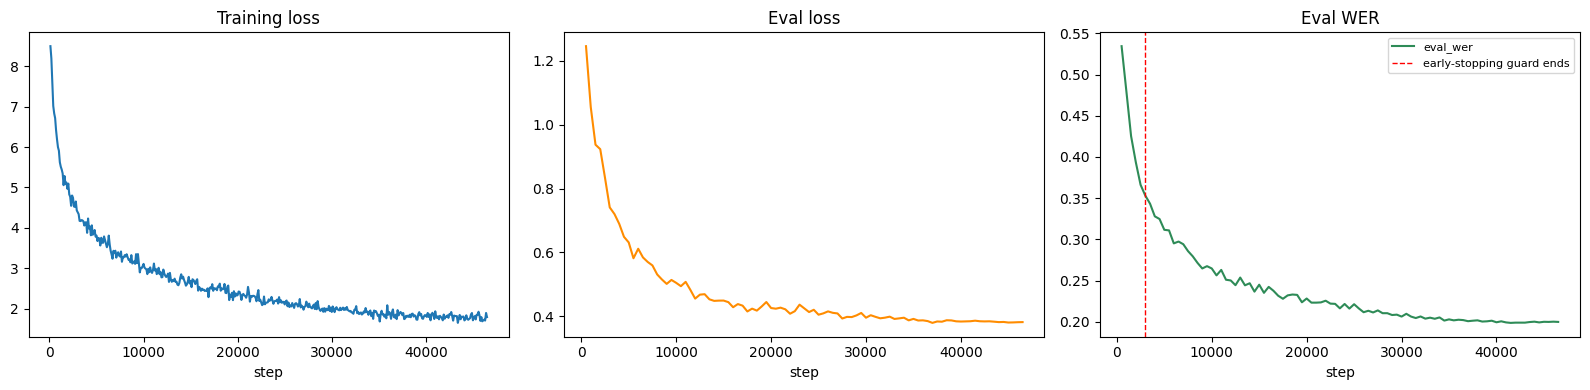

In [26]:
history_df = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if "loss" in history_df:
    history_df.dropna(subset=["loss"]).plot(x="step", y="loss", ax=axes[0], legend=False)
    axes[0].set_title("Training loss")

if "eval_loss" in history_df:
    history_df.dropna(subset=["eval_loss"]).plot(x="step", y="eval_loss", ax=axes[1], legend=False, color="darkorange")
    axes[1].set_title("Eval loss")

if "eval_wer" in history_df:
    history_df.dropna(subset=["eval_wer"]).plot(x="step", y="eval_wer", ax=axes[2], legend=False, color="seagreen")
    axes[2].axvline(x=MIN_STEPS_BEFORE_EARLY_STOPPING, color="red", linestyle="--", linewidth=1,
                     label="early-stopping guard ends")
    axes[2].set_title("Eval WER")
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Final validation metrics

Runs on `val_proc_full` — all of validation, filtered only for CTC
validity — directly comparable to notebook 04's 58.4% baseline corpus
WER on the same split.


In [27]:
final_metrics = trainer.evaluate(eval_dataset=val_proc_full)
final_metrics

{'eval_loss': 0.42250099778175354,
 'eval_model_preparation_time': 0.0045,
 'eval_wer': 0.19471597036212474,
 'eval_cer': 0.09501638509970324,
 'eval_runtime': 329.7184,
 'eval_samples_per_second': 26.356,
 'eval_steps_per_second': 6.59,
 'epoch': 14.696641643619122}

## Training summary

In [28]:
print("epochs trained:", trainer.state.epoch)
print("best checkpoint:", trainer.state.best_model_checkpoint)
print("best eval WER during training:", trainer.state.best_metric)
print("final full-validation WER:", final_metrics.get("eval_wer"))
print("final full-validation CER:", final_metrics.get("eval_cer"))
print("model saved to:", OUTPUT_DIR)

with open(OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump({
        "model_name": MODEL_NAME,
        "lr": LR,
        "warmup_ratio": WARMUP_RATIO,
        "lr_scheduler_type": LR_SCHEDULER_TYPE,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
        "gradient_checkpointing": GRADIENT_CHECKPOINTING,
        "fp16": FP16,
        "group_by_length": GROUP_BY_LENGTH,
        "weight_decay": WEIGHT_DECAY,
        "freeze_feature_encoder": FREEZE_FEATURE_ENCODER,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "min_steps_before_early_stopping": MIN_STEPS_BEFORE_EARLY_STOPPING,
        "eval_subset_size_during_training": EVAL_SUBSET_SIZE_DURING_TRAINING,
        "max_audio_duration_sec": MAX_AUDIO_DURATION_SEC,
        "smoke_test": SMOKE_TEST,
        "seed": SEED,
        "final_full_val_wer": final_metrics.get("eval_wer"),
        "final_full_val_cer": final_metrics.get("eval_cer"),
    }, f, indent=2)

print("training_config.json written.")

epochs trained: 14.696641643619122
best checkpoint: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp_debug\checkpoint-41500
best eval WER during training: 0.19858781994704325
final full-validation WER: 0.19471597036212474
final full-validation CER: 0.09501638509970324
model saved to: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp_debug
training_config.json written.


## Conclusion

Fine-tuning is complete and the best checkpoint (selected by validation
WER, with early stopping correctly delayed past the blank-collapse
window) is saved to `models/wav2vec2_slurp_debug/`, along with the
processor and a `training_config.json` recording exactly how this run
was configured.

This version additionally fixes the memory-pipeline issue flagged in
review: `Dataset.from_list()` + `.map()` is gone, replaced by
`SLURPLazyDataset`'s per-item lazy decoding, `to_rows()` no longer
decodes every file twice, and `group_by_length` is restored via
`LengthGroupedTrainer` using cached-duration lengths instead of an
Arrow column. `ArrowMemoryError` should no longer occur, and this
pipeline should scale to datasets much larger than SLURP.

**How to tell if the training fix actually worked:** look at `best eval
WER during training` above. If it's meaningfully below ~0.90-0.95
(rather than frozen near 0.956 again), `eval_wer` genuinely moved
during training.
